# EV Risk Scoring Model

## Section 1: Data Loading

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

plt.style.use("ggplot") 
np.random.seed(42)

risk_matrix=pd.read_excel("Week3_EV_RiskFactorMatrix_Group_B.xlsx", skiprows=3)
risk_matrix=risk_matrix.dropna(subset=["Risk Factor"])
risk_matrix.head()


,#,Risk Factor,Category,Description / Driver,"Probability\n(1=Low, 5=High)","Severity\n(1=Low, 5=High)",Risk Score\n(P × S),Risk Level,Proposed\nLoading %,Key Data Source,Underwriting Action
1,1,Thermal Runaway — NMC/NCA Chemistry,Battery,NMC/NCA cells release ~300 kJ/Ah on failure vs...,4.0,5.0,20.0,CRITICAL,30–45%,NFPA 855; NHTSA SGO 2021-01; Week 2 Memo S2,Apply NMC/NCA surcharge; require fire suppress...
2,2,Thermal Runaway — LFP Chemistry,Battery,LFP thermal onset at 270°C vs 210°C (NMC); sig...,2.0,4.0,8.0,MEDIUM,10–18%,NFPA 855; BYD Atto 3 spec sheet; Week 2 Memo S1,Base loading; LFP discount vs NMC baseline
3,3,Battery Degradation & Capacity Loss,Battery,LFP retains ~80% capacity at 150k km; NMC degr...,3.0,3.0,9.0,MEDIUM,8–15%,MIT Battery Lab 2023; Tesla Battery Report 2024,Require annual battery health cert after Year ...
4,4,Battery Management System (BMS) Failure,Battery,"BMS failure can allow overcharge, cell imbalan...",2.0,5.0,10.0,HIGH,15–25%,NHTSA complaints EV database; OEM recall notices,Exclusion clause for non-OEM BMS modifications...
5,5,Battery Flood / Water Ingress,Battery,Malaysia's monsoon season creates elevated flo...,4.0,4.0,16.0,HIGH,20–30%,PICC China flood data 2020; Malaysia flood sta...,Flood zone surcharge; require IP67/IP68 batter...


In [35]:
fleet_mix = {
    "BYD_Atto3_LFP": 0.32,
    "Tesla_M3_NMC": 0.18, # 18% Tesla Model 3 LR (NMC)
    "Tesla_M3_NCA": 0.06, # 6% Tesla Model 3 Performance (NCA)
    "Hyundai_Ioniq5": 0.12, # 12% Hyundai Ioniq 5 (NMC)
    "BMW_iX": 0.05, # 5% BMW iX (NMC)
    "Other_BEV": 0.27 # 27% other models
}

N=10000
vehicles=np.random.choice(list(fleet_mix.keys()),size=N,p=list(fleet_mix.values()))

chemistry_map = {
    "BYD_Atto3_LFP": "LFP",
    "Tesla_M3_NMC": "NMC", 
    "Tesla_M3_NCA": "NCA", 
    "Hyundai_Ioniq5": "NMC", 
    "BMW_iX": "NMC", 
    "Other_BEV": "NMC" 
}

si_map = {
    "BYD_Atto3_LFP": (130000, 160000),
    "Tesla_M3_NMC": (185000, 215000),
    "Tesla_M3_NCA": (225000, 250000),
    "Hyundai_Ioniq5":(175000, 210000),
    "BMW_iX": (440000, 550000),
    "Other_BEV": (90000, 160000)    
}

adas_map = {
    'BYD_Atto3_LFP': 'BYD_DiPilot',
    'Tesla_M3_NMC': 'Tesla_Autopilot',
    'Tesla_M3_NCA': 'Tesla_Autopilot',
    'Hyundai_Ioniq5': 'Level1',
    'BMW_iX': 'Level1',
    'Other_BEV': 'None'
}

## Section 2: Exploratory Data Analysis

In [3]:
risk_matrix["Category"].value_counts()

Category
Battery           8
ADAS              7
Repair Cost       5
Environmental     5
Residual Value    4
Infrastructure    4
Name: count, dtype: int64

In [4]:
risk_matrix["Risk Score\n(P × S)"].describe()

count    33.000000
mean     11.484848
std       4.458988
min       4.000000
25%       9.000000
50%      12.000000
75%      15.000000
max      20.000000
Name: Risk Score\n(P × S), dtype: float64

<Axes: >

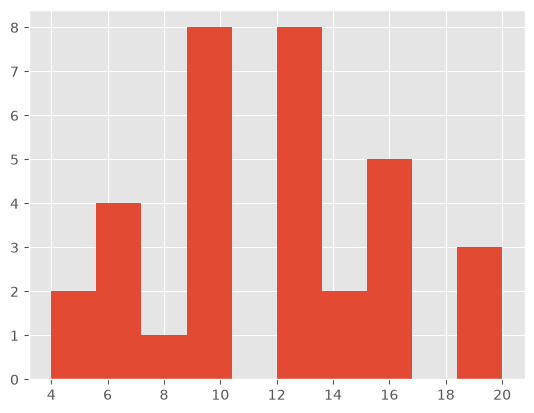

In [5]:
risk_matrix["Risk Score\n(P × S)"].hist()

## Section 3: Risk Factor Definition and Weighing

In [6]:
risk_lookup=dict(zip(risk_matrix["Risk Factor"],risk_matrix["Risk Score\n(P × S)"]))

In [131]:
def battery_score(chemistry, age):

    base = {

        "LFP":8,
        "NMC":20,
        "NCA":20

    }[chemistry]

    degradation_rate = {

        "LFP":1.8,
        "NMC":3.5,
        "NCA":3.5

    }[chemistry]

    health = 100 - age * degradation_rate

    penalty = 0

    if health < 75:
        penalty = 8

    elif health < 85:
        penalty = 4

    return base + penalty

adas_score = {
    "None": 0,
    "Level1": 4,
    "BYD_DiPilot": 9,
    "Tesla_Autopilot": 16
}

state_score = {
    "KL": 5,
    "Penang": 8,
    "Selangor": 10,
    "Other": 10,
    "Johor": 16
}

def age_score(age):

    if age < 25:
        return 20

    elif age < 35:
        return 15

    elif age < 50:
        return 10

    return 5

def experience_score(exp):

    if exp == 0:
        return 20

    elif exp <= 2:
        return 15

    elif exp <= 4:
        return 10

    return 5

def km_score(km):

    if km < 10000:
        return 5

    elif km < 20000:
        return 10

    elif km < 30000:
        return 15

    return 20

garage_score = {

    "covered":5,
    "basement":10,
    "open":16

}

def value_score(value):

    if value < 120000:
        return 5

    elif value < 220000:
        return 10

    elif value < 300000:
        return 15

    return 20

def frequency_score(row):

    return (

        age_score(row.driver_age)

        + experience_score(
            row.ev_experience_years
        )

        + km_score(
            row.annual_km
        )

        + garage_score[
            row.garaging
        ]
        + adas_score[
            row.adas_level
        ]
        + state_score[
            row.state
        ]
    )

def severity_score(row):

    return (

        battery_score(
            row.battery_chemistry,
            row.vehicle_age
        )

        + adas_score[
            row.adas_level
        ]

        + state_score[
            row.state
        ]

        + value_score(
            row.sum_insured
        )

    )

def vehicle_alpha_beta(row):

    F = frequency_score(row)

    S = severity_score(row)

    alpha = F / (F + S)

    beta = S / (F + S)

    return pd.Series([alpha,beta])



## Section 4: Risk Score Calculator

In [132]:
A = 10

def cobb_douglas(row):

    F = frequency_score(row)

    S = severity_score(row)

    return (

        A
        *
        (F ** row.alpha)
        *
        (S ** row.beta)

    )


## Section 5: Bayesian Update Demonstration

In [38]:
#PRIOR DISTRIBUTION

alpha_prior=9.5
beta_prior=90.5

prior_mean= alpha_prior/(alpha_prior+beta_prior)
print("Prior Mean:", round(prior_mean*100,2), "%")

prior_dist=stats.beta(alpha_prior,beta_prior)
prior_ci=prior_dist.ppf([0.025,0.975])
print(f"Prior 95% CI: [{prior_ci[0]:.2%}, {prior_ci[1]:.2%}]")


#CURRENT MALAYSIAN DATA

n_observed=0
x_observed=0

print(
    f"\nObserved Data: {x_observed} claims out of {n_observed} policies"
)

#POSTERIOR UPDATE

alpha_post = alpha_prior + x_observed
beta_post = beta_prior + (n_observed - x_observed)

posterior_dist = stats.beta(alpha_post, beta_post)

posterior_mean = (
    alpha_post /
    (alpha_post + beta_post)
)

posterior_ci = posterior_dist.ppf([0.025,0.975])

print(
    f"Posterior Mean: {posterior_mean:.2%}"
)

print(
    f"Posterior 95% CI: [{posterior_ci[0]:.2%}, {posterior_ci[1]:.2%}]"
)




Prior Mean: 9.5 %
Prior 95% CI: [4.59%, 15.93%]

Observed Data: 0 claims out of 0 policies
Posterior Mean: 9.50%
Posterior 95% CI: [4.59%, 15.93%]


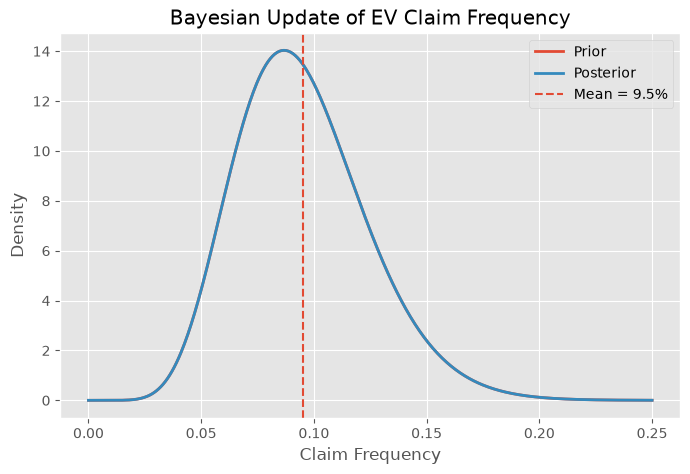

In [39]:
x_vals = np.linspace(0,0.25,500)

plt.figure(figsize=(8,5))

plt.plot(
    x_vals,
    prior_dist.pdf(x_vals),
    label="Prior",
    linewidth=2
)

plt.plot(
    x_vals,
    posterior_dist.pdf(x_vals),
    label="Posterior",
    linewidth=2
)

plt.axvline(
    posterior_mean,
    linestyle="--",
    label=f"Mean = {posterior_mean:.1%}"
)

plt.title("Bayesian Update of EV Claim Frequency")
plt.xlabel("Claim Frequency")
plt.ylabel("Density")
plt.legend()

plt.show()

In [40]:
prior_scenarios = [
    {"name":"Optimistic (7%)","alpha":7.0,"beta":93.0},
    {"name":"Conservative (8%)","alpha":8.0,"beta":92.0},
    {"name":"Our Estimate (9.5%)","alpha":9.5,"beta":90.5},
    {"name":"Cautious (12%)","alpha":12.0,"beta":88.0},
    {"name":"Pessimistic (15%)","alpha":15.0,"beta":85.0},
]

results=[]

for sc in prior_scenarios:

    a=sc["alpha"]
    b=sc["beta"]

    post_a=a+x_observed
    post_b=b+(n_observed-x_observed)

    post_mean=post_a/(post_a+post_b)

    post_dist=stats.beta(post_a,post_b)

    ci=post_dist.ppf([0.025,0.975])

    results.append({
        "Scenario":sc["name"],
        "Posterior Mean":f"{post_mean:.2%}",
        "95% CI":f"[{ci[0]:.2%},{ci[1]:.2%}]"
    })

sens_df=pd.DataFrame(results)

sens_df

,Scenario,Posterior Mean,95% CI
0,Optimistic (7%),7.00%,"[2.89%,12.73%]"
1,Conservative (8%),8.00%,"[3.55%,14.03%]"
2,Our Estimate (9.5%),9.50%,"[4.59%,15.93%]"
3,Cautious (12%),12.00%,"[6.42%,19.01%]"
4,Pessimistic (15%),15.00%,"[8.74%,22.59%]"


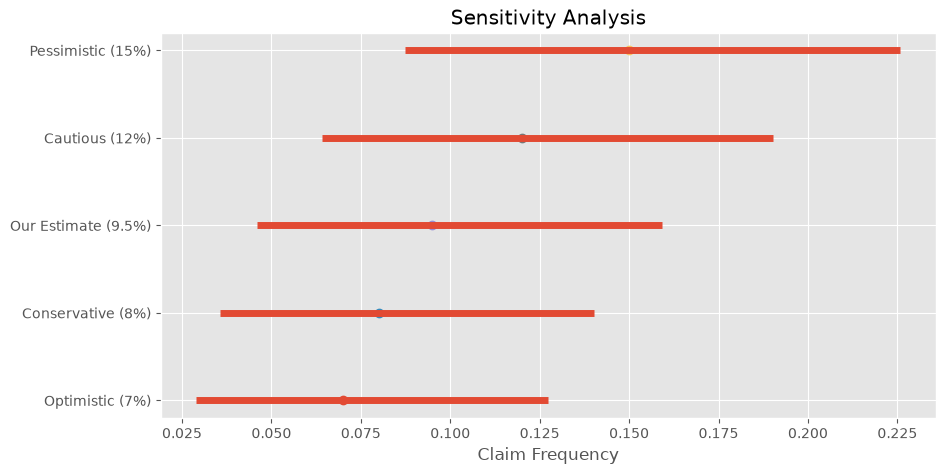

In [41]:
plt.figure(figsize=(10,5))

for i,sc in enumerate(prior_scenarios):

    dist=stats.beta(
        sc["alpha"]+x_observed,
        sc["beta"]+(n_observed-x_observed)
    )

    ci=dist.ppf([0.025,0.975])

    mean=(sc["alpha"]+x_observed)/(
        sc["alpha"]+sc["beta"]+n_observed
    )

    plt.plot(mean,i,'o')
    plt.hlines(
        y=i,
        xmin=ci[0],
        xmax=ci[1],
        linewidth=5
    )

plt.yticks(
    range(len(prior_scenarios)),
    [s["name"] for s in prior_scenarios]
)

plt.xlabel("Claim Frequency")
plt.title("Sensitivity Analysis")
plt.show()

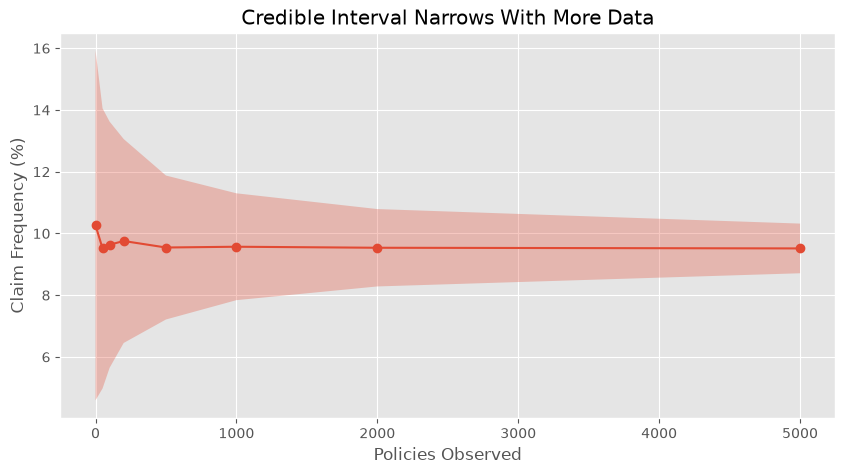

In [42]:
sample_sizes=[0,50,100,200,500,1000,2000,5000]

lower=[]
upper=[]

for n in sample_sizes:

    x=int(0.095*n)

    dist=stats.beta(
        alpha_prior+x,
        beta_prior+n-x
    )

    ci=dist.ppf([0.025,0.975])

    lower.append(ci[0]*100)
    upper.append(ci[1]*100)

plt.figure(figsize=(10,5))

plt.fill_between(
    sample_sizes,
    lower,
    upper,
    alpha=0.3
)

plt.plot(
    sample_sizes,
    [(a+b)/2 for a,b in zip(lower,upper)],
    marker='o'
)

plt.xlabel("Policies Observed")
plt.ylabel("Claim Frequency (%)")

plt.title("Credible Interval Narrows With More Data")

plt.show()

## Section 6: Synthetic Scenario Testing

In [133]:
df=pd.DataFrame({
    "vehicle_type":vehicles,
    "battery_chemistry":[chemistry_map[v] for v in vehicles],
    "vehicle_age":np.random.choice([1,2,3,4,5],N,p=[0.30,0.35,0.20,0.10,0.05]), 
    "adas_level":[adas_map[v] for v in vehicles],
    "driver_age": np.random.normal(38,10,N).clip(18,75).astype(int),
    "ev_experience_years": np.random.choice([0,1,2,3], N, p=[0.3,0.35,0.25,0.1]),
    "garaging": np.random.choice(["basement","covered","open"], N, p=[0.25,0.35,0.40]),
    "state": np.random.choice(["Selangor","KL","Johor","Penang","Other"], N, p=[0.30,0.15,0.15,0.10,0.30]),
    "annual_km": np.random.normal(18000,6000, N).clip(5000,60000),
    "sum_insured": [np.random.randint(*si_map[v]) for v in vehicles]
})

df[["alpha","beta"]] = df.apply(
    vehicle_alpha_beta,
    axis=1
)
df["raw_risk_score"] = df.apply(
    cobb_douglas,
    axis=1
)
min_score = df["raw_risk_score"].min()
max_score = df["raw_risk_score"].max()

df["risk_score"] = (

    (df["raw_risk_score"] - min_score)

    /

    (max_score - min_score)

) * 100
df["latent_risk"] = np.random.lognormal(
    mean=0,
    sigma=0.15,
    size=len(df)
)

df["risk_band"] = pd.qcut(
    df["risk_score"],
    5,
    labels=["Very Low","Low","Medium","High","Very High"]
)


df


,vehicle_type,battery_chemistry,vehicle_age,adas_level,driver_age,ev_experience_years,garaging,state,annual_km,sum_insured,alpha,beta,raw_risk_score,risk_score,latent_risk,risk_band
0,Tesla_M3_NMC,NMC,3,Tesla_Autopilot,61,2,open,Other,17824.382033,190777,0.562500,0.437500,645.032788,58.318391,0.898607,High
1,Other_BEV,NMC,1,None,27,3,open,KL,18981.280249,145220,0.615385,0.384615,467.390996,23.204384,1.113920,Very Low
2,Other_BEV,NMC,2,None,43,1,basement,Penang,12518.090470,101706,0.616279,0.383721,441.896651,18.164981,1.084159,Very Low
3,Hyundai_Ioniq5,NMC,1,Level1,35,1,covered,Other,6271.068495,197264,0.526882,0.473118,465.672853,22.864763,0.978424,Very Low
4,BYD_Atto3_LFP,LFP,5,BYD_DiPilot,42,0,open,Other,16172.703643,148650,0.669643,0.330357,593.865400,48.204262,0.879116,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,Other_BEV,NMC,1,None,26,3,open,Johor,25431.559789,116105,0.637168,0.362832,586.951827,46.837674,1.168048,Medium
9996,Other_BEV,NMC,1,None,47,2,open,Selangor,13680.986693,107345,0.635417,0.364583,498.161095,29.286632,1.095648,Low
9997,Other_BEV,NMC,1,None,38,0,basement,Selangor,17039.374941,110164,0.631579,0.368421,491.937658,28.056461,1.038191,Very Low
9998,Tesla_M3_NMC,NMC,1,Tesla_Autopilot,36,3,covered,Penang,15595.562071,196347,0.522124,0.477876,565.553549,42.607930,0.942824,Medium


In [134]:
base_freq=posterior_mean

garage_freq = {

    'basement': 1.00,

    'covered': 0.95,

    'open': 1.10

}

age_freq = df['driver_age'].apply(

    lambda a: 1.15 if a < 25

    else (0.95 if a > 55 else 1.00)

)

exp_freq = df['ev_experience_years'].map({

    0: 1.15,

    1: 1.08,

    2: 1.00,

    3: 0.95

})

adas_freq = {
    "None": 1.15,
    "Level1": 1.00,
    "BYD_DiPilot": 0.90,
    "Tesla_Autopilot": 0.85
}

vehicle_age_freq = np.where(
    df["vehicle_age"] <= 2, 1.00,
    np.where(df["vehicle_age"] <= 4, 1.10, 1.20)
)

km_freq = df['annual_km'].apply(

    lambda km: 0.90 if km < 10000

    else (1.00 if km < 20000

    else (1.10 if km < 30000

    else 1.20))

)

state_freq = {

    'KL': 0.95,

    'Penang': 1.00,

    'Selangor': 1.05,

    'Other': 1.05,

    'Johor': 1.10

}

df["claim_probability"]=((base_freq)*df["garaging"].map(garage_freq)*df["adas_level"].map(adas_freq)*vehicle_age_freq*age_freq.values* exp_freq.values* km_freq.values*df["state"].map(state_freq)*df["latent_risk"]).clip(0.01, 0.40)

df["had_claim"]=np.random.binomial(1,df["claim_probability"])

def claim_type(row):

    total_loss_prob = 0.05
    major_prob = 0.25

    # Battery chemistry effect
    if row["battery_chemistry"] == "NMC":
        total_loss_prob += 0.05

    elif row["battery_chemistry"] == "NCA":
        total_loss_prob += 0.07

    # ADAS effect
    if row["adas_level"] == "Tesla_Autopilot":
        total_loss_prob += 0.04

    elif row["adas_level"] == "BYD_DiPilot":
        total_loss_prob += 0.02

    # State effect
    if row["state"] == "Johor":
        total_loss_prob += 0.03

    elif row["state"] == "Selangor":
        total_loss_prob += 0.01

    total_loss_prob = min(total_loss_prob, 0.25)

    minor_prob = 1 - major_prob - total_loss_prob

    return np.random.choice(
        ["minor", "major", "total_loss"],
        p=[minor_prob, major_prob, total_loss_prob]
    )

df["claim_type"] = df.apply(
    lambda row: claim_type(row)
    if row["had_claim"] == 1
    else "No Claim",
    axis=1
)

def severity(row):

    si = row["sum_insured"]

    if row["claim_type"] == "minor":
        cost = np.random.uniform(0.05, 0.20) * si

    elif row["claim_type"] == "major":
        cost = np.random.uniform(0.20, 0.60) * si

    elif row["claim_type"] == "total_loss":
        cost = si

    else:
        return 0

    battery_mult = {
        "LFP": 1.00,
        "NMC": 1.15,
        "NCA": 1.25
    }

    return cost * battery_mult[row["battery_chemistry"]]

df["claim_cost"] = df.apply(severity, axis=1)


claim_losses=df["claim_cost"][df["claim_cost"]>0]

expected_loss=df["claim_cost"].mean()

var95=np.percentile(
    claim_losses,
    95
)

print(
    f"Claim Frequency: {df["had_claim"].mean():.2%}"
)

print(
    f"Expected Loss: RM {expected_loss:,.0f}"
)

print(
    f"95% VaR: RM {var95:,.0f}"
)

df.groupby(
    pd.qcut(df["risk_score"],5)
)["claim_probability"].mean()

Claim Frequency: 11.50%
Expected Loss: RM 6,810
95% VaR: RM 216,650


risk_score
(-0.001, 28.977]    0.110533
(28.977, 38.739]    0.117213
(38.739, 46.914]    0.119883
(46.914, 58.724]    0.113727
(58.724, 100.0]     0.111919
Name: claim_probability, dtype: float64

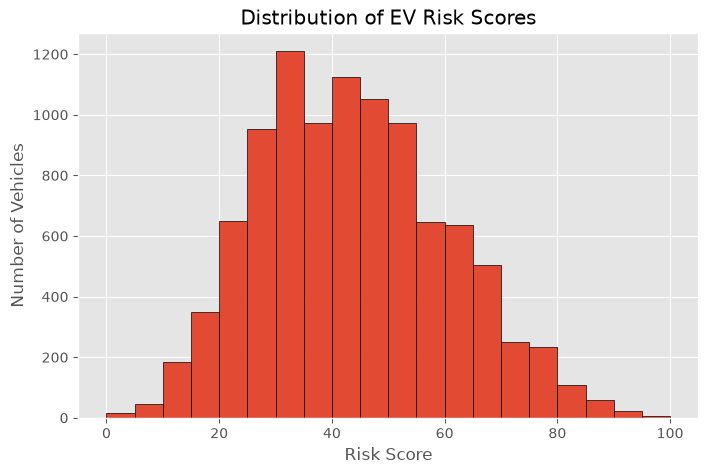

In [135]:
plt.figure(figsize=(8,5))



plt.hist(df["risk_score"], bins=20, edgecolor="black")



plt.title("Distribution of EV Risk Scores")

plt.xlabel("Risk Score")

plt.ylabel("Number of Vehicles")



plt.show()

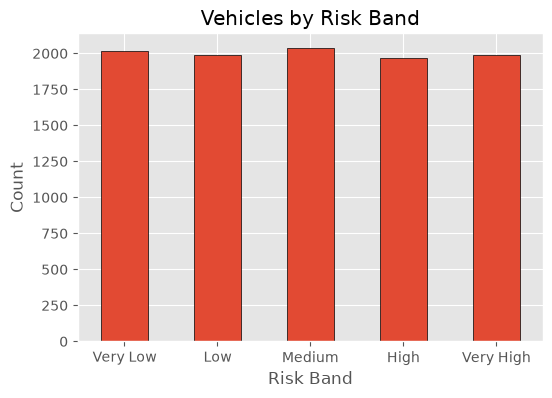

In [136]:
plt.figure(figsize=(6,4))

df["risk_band"].value_counts().sort_index().plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Vehicles by Risk Band")
plt.xlabel("Risk Band")
plt.ylabel("Count")

plt.xticks(rotation=0)

plt.show()

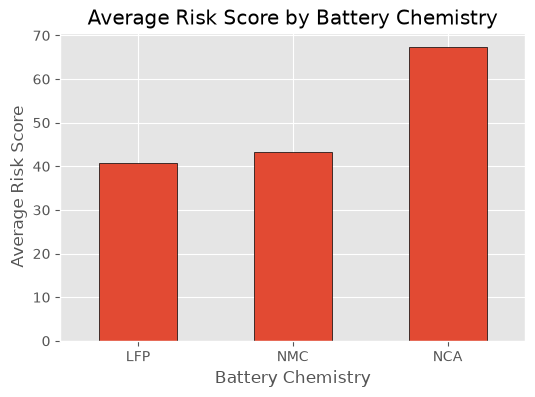

In [137]:
plt.figure(figsize=(6,4))

df.groupby("battery_chemistry")["risk_score"] \
  .mean() \
  .sort_values() \
  .plot(kind="bar", edgecolor="black")

plt.title("Average Risk Score by Battery Chemistry")
plt.xlabel("Battery Chemistry")
plt.ylabel("Average Risk Score")

plt.xticks(rotation=0)

plt.show()

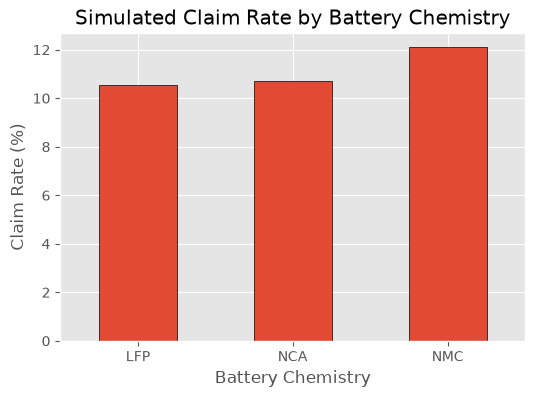

In [138]:
claim_rate = (
    df.groupby("battery_chemistry")["had_claim"]
      .mean()*100
)

plt.figure(figsize=(6,4))

claim_rate.plot(
    kind="bar",
    edgecolor="black"
)

plt.ylabel("Claim Rate (%)")
plt.xlabel("Battery Chemistry")
plt.title("Simulated Claim Rate by Battery Chemistry")

plt.xticks(rotation=0)

plt.show()

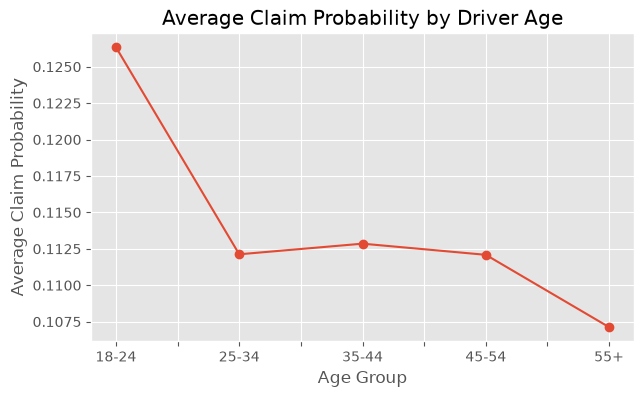

In [87]:
df["age_group"] = pd.cut(
    df["driver_age"],
    bins=[18,25,35,45,55,75],
    labels=["18-24","25-34","35-44","45-54","55+"]
)

plt.figure(figsize=(7,4))

df.groupby("age_group")["claim_probability"] \
  .mean() \
  .plot(marker="o")

plt.title("Average Claim Probability by Driver Age")
plt.xlabel("Age Group")
plt.ylabel("Average Claim Probability")

plt.grid(True)

plt.show()

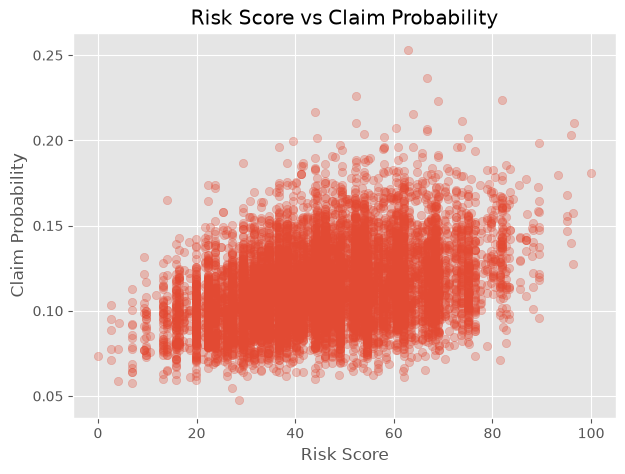

In [88]:
plt.figure(figsize=(7,5))

plt.scatter(
    df["risk_score"],
    df["claim_probability"],
    alpha=0.3
)

plt.title("Risk Score vs Claim Probability")
plt.xlabel("Risk Score")
plt.ylabel("Claim Probability")

plt.show()

In [89]:
top10 = (
    df.nlargest(10,"risk_score")
    [["vehicle_type",
      "battery_chemistry",
      "driver_age",
      "annual_km",
      "risk_score"]]
)

top10

,vehicle_type,battery_chemistry,driver_age,annual_km,risk_score
8588,Tesla_M3_NCA,NCA,18,27015.941223,100.000000
5067,Tesla_M3_NMC,NMC,24,30298.158601,96.581404
1484,Tesla_M3_NMC,NMC,20,20497.424562,96.286253
8768,Tesla_M3_NMC,NMC,28,32916.548391,96.286253
6146,Tesla_M3_NCA,NCA,29,24830.248497,95.890451
9067,Tesla_M3_NCA,NCA,24,20098.038610,95.890451
2737,Tesla_M3_NCA,NCA,19,20240.098103,95.070743
2896,Tesla_M3_NCA,NCA,18,26246.967153,95.070743
4053,Tesla_M3_NCA,NCA,24,29864.956717,95.070743
6514,Tesla_M3_NCA,NCA,18,20732.052542,95.070743


In [121]:
print("Average Risk Score :", round(df["risk_score"].mean(),2))
print("Average Claim Probability :", round(df["claim_probability"].mean()*100,2),"%")
print("Overall Simulated Claim Rate :", round(df["had_claim"].mean()*100,2),"%")

print("\nRisk Band Distribution")
print(df["risk_band"].value_counts(normalize=True)*100)

Average Risk Score : 43.3
Average Claim Probability : 11.47 %
Overall Simulated Claim Rate : 11.93 %

Risk Band Distribution
risk_band
High         21.05
Very Low     20.44
Medium       20.30
Low          19.64
Very High    18.57
Name: proportion, dtype: float64


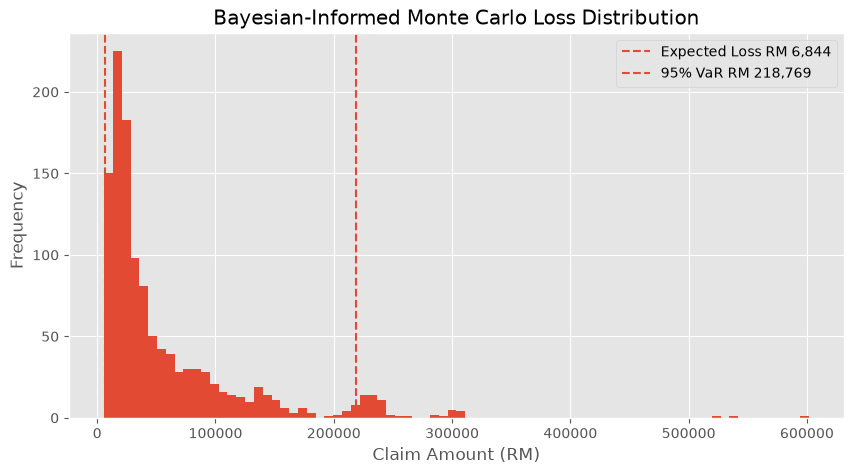

In [122]:
plt.figure(figsize=(10,5))

plt.hist(
    claim_losses,
    bins=80
)

plt.axvline(
    expected_loss,
    linestyle='--',
    label=f'Expected Loss RM {expected_loss:,.0f}'
)

plt.axvline(
    var95,
    linestyle='--',
    label=f'95% VaR RM {var95:,.0f}'
)

plt.title(
    "Bayesian-Informed Monte Carlo Loss Distribution"
)

plt.xlabel("Claim Amount (RM)")
plt.ylabel("Frequency")

plt.legend()

plt.show()



## Section 7: Conclusions

In [139]:
print("\n=== Mean Risk Score by Battery Chemistry ===")
print(
    df.groupby("battery_chemistry")["risk_score"]
      .agg(["count","mean","median","min","max"])
      .round(2)
)


=== Mean Risk Score by Battery Chemistry ===
                   count   mean  median    min     max
battery_chemistry                                     
LFP                 3245  40.67   40.54   6.88   78.83
NCA                  626  67.23   67.03  36.68  100.00
NMC                 6129  43.33   41.58   0.00   99.06


In [141]:
print(
    df.groupby("battery_chemistry")
      [["risk_score","claim_cost"]]
      .mean()
      .round(2)
)

                   risk_score  claim_cost
battery_chemistry                        
LFP                     40.67     4306.75
NCA                     67.23    11806.46
NMC                     43.33     7624.73


In [142]:
print(
    df.groupby("adas_level")
      [["risk_score","claim_cost"]]
      .mean()
      .round(2)
)

                 risk_score  claim_cost
adas_level                             
BYD_DiPilot           40.67     4306.75
Level1                41.88    10764.59
None                  30.25     5835.67
Tesla_Autopilot       64.25     8411.41


In [143]:
df["risk_decile"] = pd.qcut(
    df["risk_score"],
    10,
    labels=False
)

print(
    df.groupby("risk_decile")
      [["risk_score","claim_cost"]]
      .mean()
      .round(2)
)

             risk_score  claim_cost
risk_decile                        
0                 17.68     5296.21
1                 26.79     4082.32
2                 32.53     4949.78
3                 36.54     7414.96
4                 40.37     5500.39
5                 44.97     7483.53
6                 49.89     6825.53
7                 55.62     9768.84
8                 62.75     7816.40
9                 75.00     9943.58


In [144]:
print(
    df.groupby("risk_band")
      .agg(
          avg_risk=("risk_score","mean"),
          avg_claim_cost=("claim_cost","mean"),
          claim_rate=("had_claim","mean")
      )
      .round(2)
)

           avg_risk  avg_claim_cost  claim_rate
risk_band                                      
Very Low      22.14         4702.82        0.11
Low           33.88         5779.77        0.13
Medium        42.62         6472.01        0.12
High          52.70         8268.74        0.12
Very High     68.85         8875.72        0.10


In [145]:
top10 = df.sort_values("risk_score", ascending=False)

print(
    top10[
        [
            "risk_score",
            "battery_chemistry",
            "adas_level",
            "state",
            "driver_age",
            "ev_experience_years",
            "annual_km"
        ]
    ].head(10)
)

      risk_score battery_chemistry       adas_level  state  driver_age  \
2984  100.000000               NCA  Tesla_Autopilot  Johor          28   
125    99.059918               NMC  Tesla_Autopilot  Johor          20   
3195   97.150085               NCA  Tesla_Autopilot  Other          23   
1393   96.813249               NCA  Tesla_Autopilot  Johor          18   
5849   96.813249               NCA  Tesla_Autopilot  Johor          30   
6832   96.813249               NCA  Tesla_Autopilot  Johor          28   
5354   96.813249               NCA  Tesla_Autopilot  Johor          31   
1267   93.835087               NMC  Tesla_Autopilot  Other          18   
5503   93.039593               NMC  Tesla_Autopilot  Johor          18   
7727   93.039593               NMC  Tesla_Autopilot  Johor          18   

      ev_experience_years     annual_km  
2984                    0  29976.527373  
125                     0  22549.642738  
3195                    0  34250.374946  
1393             

In [146]:
print(
    df.groupby("risk_decile")
      .agg(
          avg_risk=("risk_score","mean"),
          claim_rate=("had_claim","mean"),
          avg_claim_cost=("claim_cost","mean")
      )
      .round(3)
)

             avg_risk  claim_rate  avg_claim_cost
risk_decile                                      
0              17.683       0.116        5296.215
1              26.791       0.098        4082.322
2              32.532       0.130        4949.781
3              36.539       0.118        7414.961
4              40.372       0.115        5500.394
5              44.966       0.128        7483.533
6              49.891       0.109        6825.533
7              55.619       0.126        9768.837
8              62.753       0.101        7816.404
9              75.003       0.106        9943.578
